In [7]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #3eb911; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #004f8f">Experimenting with materials</h3>
</div>

Imports:

In [8]:
import numpy as np
import scipy.sparse.linalg as spla
from scipy.special import erf

from Utilities.fem_poisson import *
from Utilities.Mesh_processing import *

---
Material experimentation:

In [9]:
p, e, t = Plot_Initial_Refined_meshes(data_path='Meshes/Hollow_circle_mesh_data.npz',
                                      num_of_refinements=1, plot=False, figsize=(16,8))

def source_function(x, y, subdomain):
    # return np.abs(10*(np.sin(np.pi*3*y)+np.cos(np.pi*3*x)))
    r = np.sqrt((x + 1/3)**2 + y**2)
    return 10*(np.cos(np.pi*r) * np.cos(3*np.arctan2(x + 1/3,y)))

def material_map(x, y, subdomain):
    
    k1, k2 = 0.3, 130      
    r0 = 1.63 / 3            
    epsilon = 0.021
    
    r = np.sqrt((x + 1/3)**2 + y**2)
    dist = r - r0          
    
    smoothing = 0.5 * (1 + erf(dist / (epsilon * np.sqrt(2))))
    
    val = k1 + (k2 - k1) * smoothing

    return val

f_values = evalOnTrigs(p, t, source_function)
a_values = evalOnTrigs(p, t, material_map)

A_material = assembleStiffness(p, t, coef_a=a_values)
f_raw = assembleLoad(p, t, coef_f=f_values)

boundary_nodes = np.unique(e[e[:, 2] > 0, 0:2])

A_mat_bc = A_material.tolil()
f_bc = f_raw.copy()

for node in boundary_nodes:
    A_mat_bc[node, :] = 0
    A_mat_bc[node, node] = 1
    f_bc[node] = 0

u_material = spla.spsolve(A_mat_bc.tocsc(), f_bc)

In [10]:
mesh_df(p, e, t, first_n_entries=13)

p is of shape: (4537, 2)
e is of shape: (13205, 3)
t is of shape: (8668, 7)


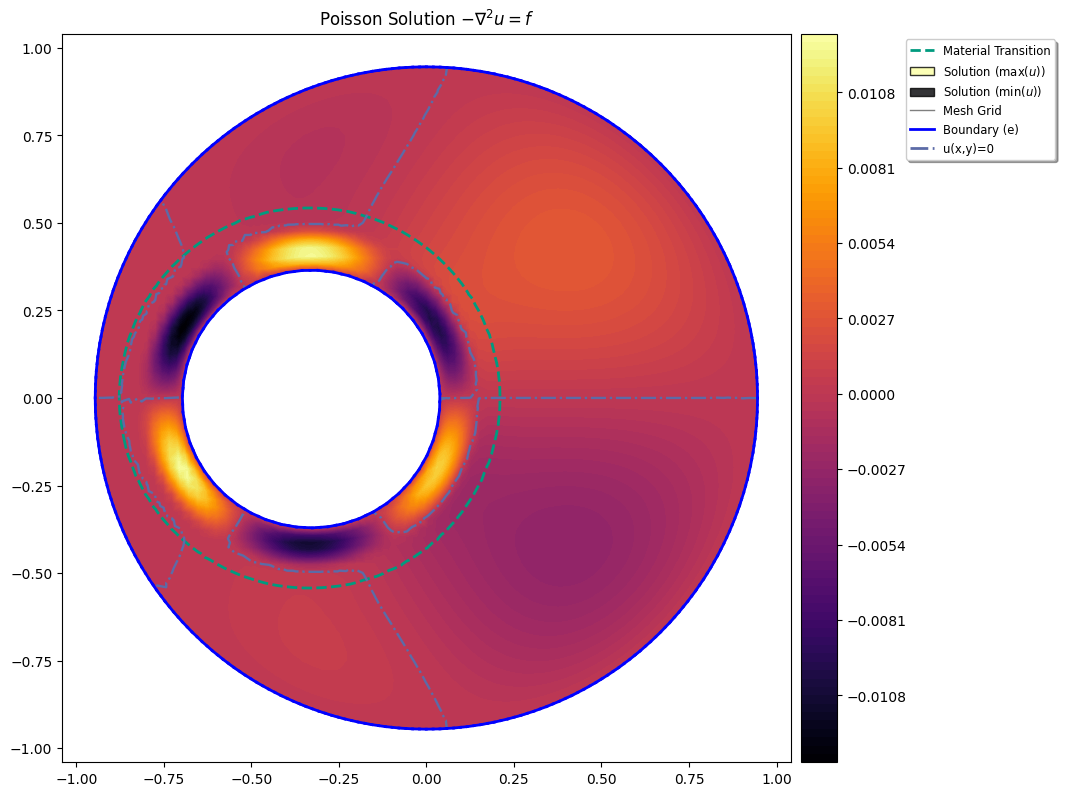

In [11]:
Plot_the_solution(u_material, p, t, e, material_function=material_map,
                  mesh_alpha=0, color_map='inferno', level_curve_number=100)

3D plot for more clarity:

In [12]:
Plot_the_solution_3d(u_material, p, t, e)